In [1]:
from functools import partial

from dotenv import load_dotenv
import os

load_dotenv()
LAT = float(os.environ.get("LAT"))
LON = float(os.environ.get("LON"))
FUSION_SOLAR_CLIENT_PASSWORD = os.environ.get("FUSION_SOLAR_CLIENT_PASSWORD")
FUSION_SOLAR_CLIENT_USERNAME = os.environ.get("FUSION_SOLAR_CLIENT_USERNAME")

In [2]:
import pandas as pd

from energymanagementrl.production_forecast import PanelModel, ArrayConfig, PlantConfig, WeatherType, \
    EnergyPredictionSystem, OpenMeteoClient, analyze_production
from energymanagementrl.fusion_solar_connector import FusionSolarClientParsed

In [3]:
open_meteo_client = OpenMeteoClient()
panel_model = PanelModel(pdc0=0.42, temp_model_a=-3.56, temp_model_b=-0.075, delta_t=3, gamma_pdc=-0.004)
num_panels = 14
arrays = [ArrayConfig(name='sud_east', panel_model=panel_model, num_panels=num_panels, tilt_angle=25, azimuth=110),
          ArrayConfig(name='nord_west', panel_model=panel_model, num_panels=num_panels, tilt_angle=18, azimuth=290)]

plant_config = PlantConfig(
    latitude=LAT, longitude=LON, timezone='Europe/Rome', inverter_pdc0=6, arrays=arrays
)
energy_prediction_system = EnergyPredictionSystem(plant_config=plant_config, open_meteo_client=open_meteo_client)

In [4]:
client = FusionSolarClientParsed(FUSION_SOLAR_CLIENT_USERNAME, FUSION_SOLAR_CLIENT_PASSWORD,
                                 huawei_subdomain="uni004eu5")
_plant_id = client.get_plant_ids()[0]
_battery_id = client.get_battery_ids(_plant_id)[0]

In [5]:
s_start = '2024-10-20 00:05'
s_end = '2024-12-19 00:05'

# s_start = '2024-12-18 00:05'
# s_end = '2024-12-19 00:05'

start = pd.Timestamp(
    s_start
    , tz='Europe/Rome'
).tz_convert('UTC').tz_convert(None)
end = pd.Timestamp(
    s_end
    , tz='Europe/Rome').tz_convert('UTC').tz_convert(None)

Total AC energy: 1632.40 kWh
Max production: 5.76 kW at 2024-10-20 08:50:00
Production starts at: 2024-10-20 05:20:00, ends at: 2024-12-18 15:40:00


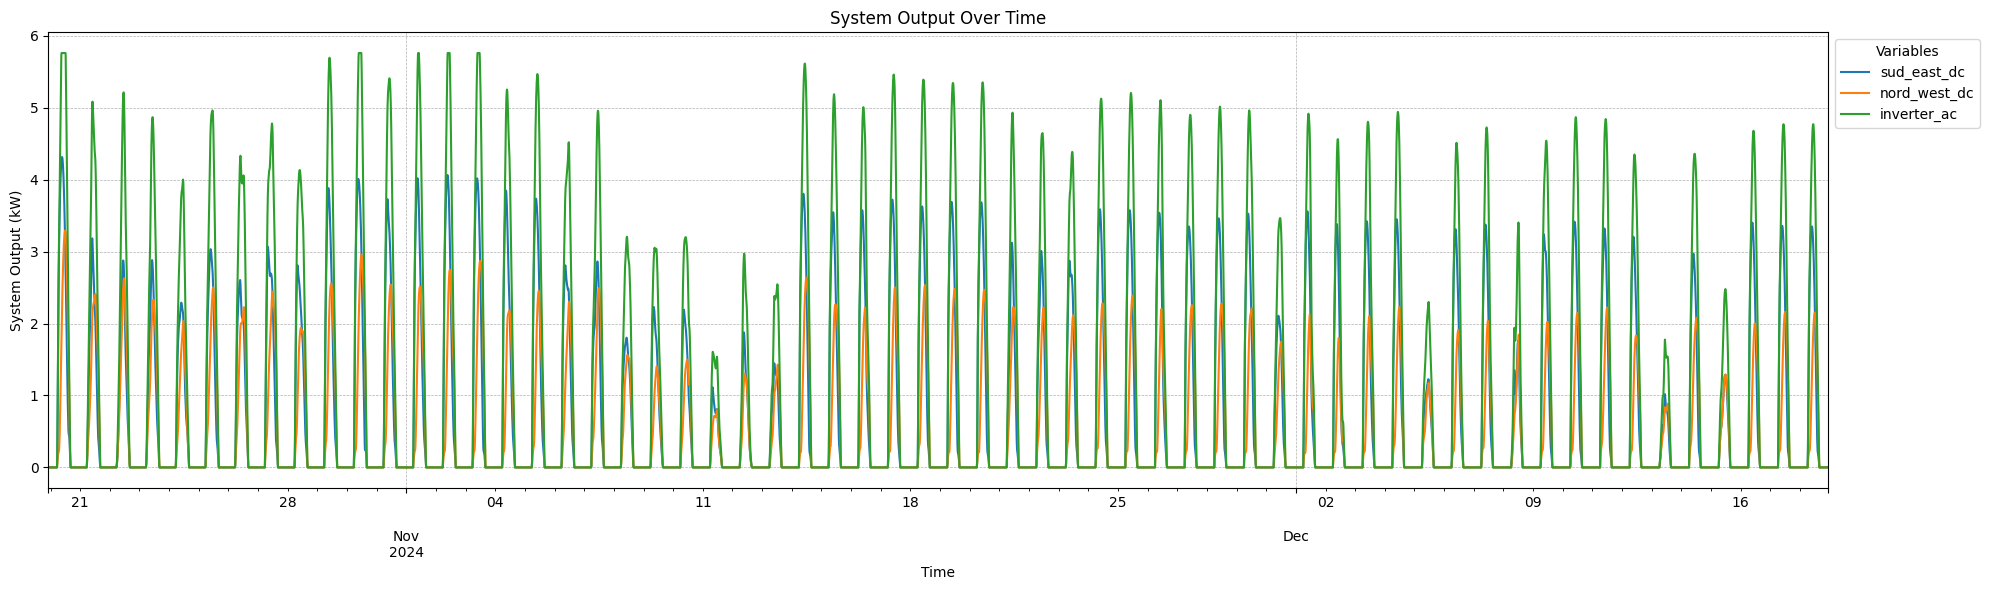

Total AC energy: 1902.46 kWh
Max production: 5.76 kW at 2024-10-20 09:05:00
Production starts at: 2024-10-20 05:25:00, ends at: 2024-12-18 15:30:00


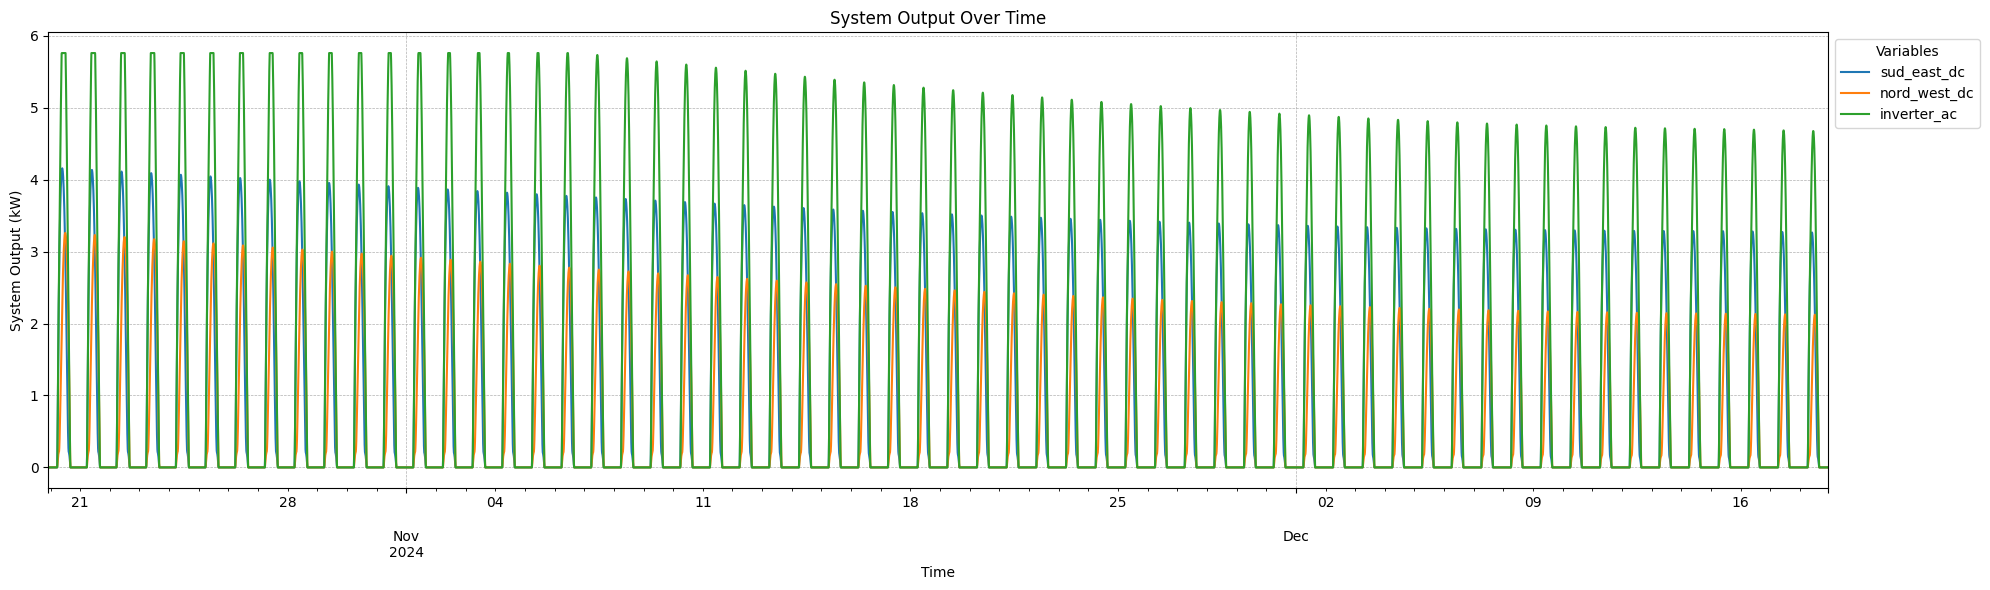

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 17293 entries, 2024-10-19 22:05:00 to 2024-12-18 23:05:00
Freq: 5min
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sud_east_dc   17293 non-null  float64
 1   nord_west_dc  17293 non-null  float64
 2   inverter_ac   17293 non-null  float64
dtypes: float64(3)
memory usage: 540.4 KB
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 17293 entries, 2024-10-19 22:05:00 to 2024-12-18 23:05:00
Freq: 5min
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sud_east_dc   17293 non-null  float64
 1   nord_west_dc  17293 non-null  float64
 2   inverter_ac   17293 non-null  float64
dtypes: float64(3)
memory usage: 540.4 KB


In [6]:
open_meteo_production_df = energy_prediction_system.run_energy_production_prediction(
    start.strftime('%Y-%m-%d %H:%M'),
    end.strftime('%Y-%m-%d %H:%M'),
    WeatherType.open_meteo
)
analyze_production(open_meteo_production_df,1/12)

clear_sky_production_df = energy_prediction_system.run_energy_production_prediction(
    start.strftime('%Y-%m-%d %H:%M'),
    end.strftime('%Y-%m-%d %H:%M'),
    WeatherType.clear_sky
)
analyze_production(clear_sky_production_df,1/12)
open_meteo_production_df.info()
clear_sky_production_df.info()

In [7]:
clear_sky_production_df.rename({'inverter_ac': 'production_power_kw_optimal'}, axis=1, inplace=True)
open_meteo_production_df.rename({'inverter_ac': 'production_power_kw_weather_dependent'}, axis=1, inplace=True)
merged_df = pd.concat([clear_sky_production_df.production_power_kw_optimal,
                       open_meteo_production_df.production_power_kw_weather_dependent], axis=1)

In [8]:
TIMEZONE_LOCAL = 'Europe/Rome'
unformatted_plant_history, final_plant_history = client.get_plant_history(pd.Timestamp(start), pd.Timestamp(end),
                                                                          _battery_id, _plant_id, TIMEZONE_LOCAL)

<Axes: >

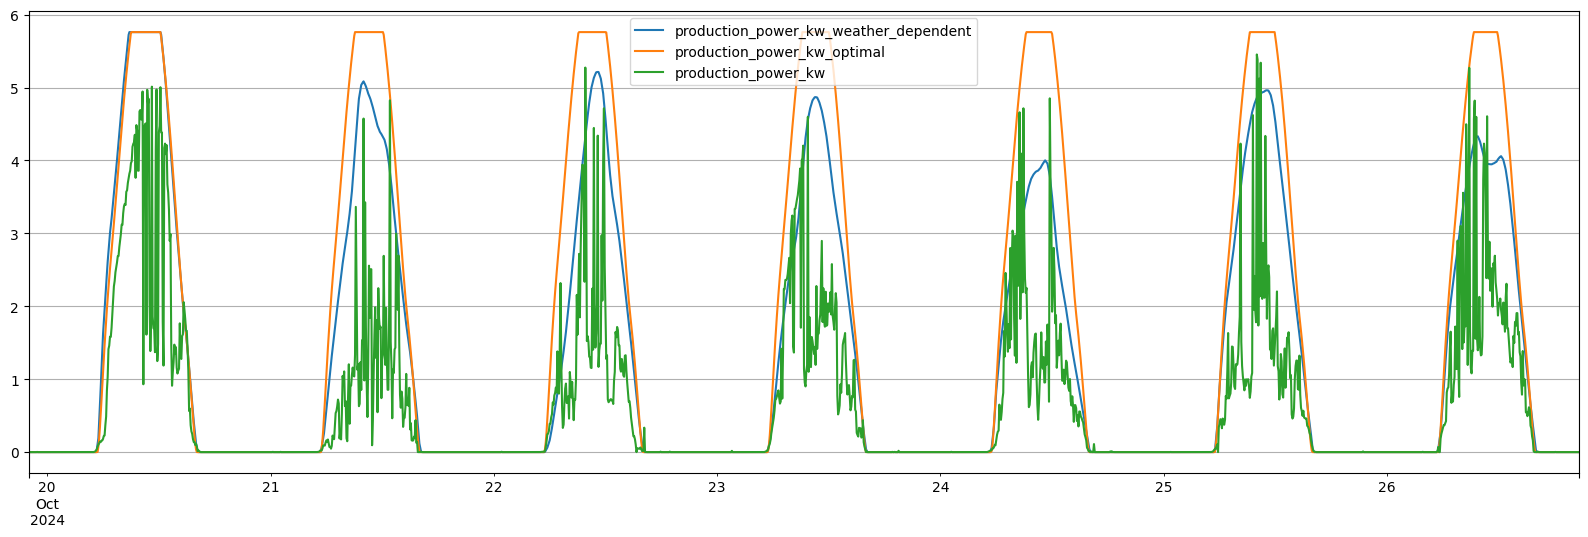

In [19]:
partial_df = pd.concat([final_plant_history, merged_df], axis=1)
i = 0
partial_df[['production_power_kw_weather_dependent', 'production_power_kw_optimal', 'production_power_kw']][
2000 * i:2000 * (i + 1)].plot(figsize=(20, 6), grid=True)

In [20]:
df=pd.read_csv('../data/complete_series.ex.12kw.csv')['grid_voltage']

In [21]:
complete_df=pd.concat([df,partial_df.reset_index()],axis=1).set_index('index').dropna()

In [22]:
complete_df.to_csv(f'../data/complete_series.{num_panels}panels.csv', index_label='index')